# DBSCAN: build, inspect, and improve a clustering model

**Goal:** turn a cloud of unlabeled points into clusters and explicitly identify noise.

This is a five-minute model-building loop:
1. Load and visualize the data.
2. Choose `eps` (neighborhood radius) and `min_samples` (density threshold).
3. Fit DBSCAN and inspect cluster/noise counts.
4. Visualize core points, border points, and noise.
5. Change one parameter and compare the result.

> DBSCAN does not choose the number of clusters in advance. It discovers dense regions. In scikit-learn, a **core point** has at least `min_samples` points (including itself) within distance `eps`. Clusters expand through connected core points; reachable non-core points are border points; remaining points receive label `-1` (noise).

## 1. Import the tools

We use pandas to load the data, scikit-learn to fit DBSCAN, and matplotlib to make the model's decisions visible.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors

plt.style.use("seaborn-v0_8-whitegrid")
RANDOM_STATE = 42  # Keeps any future random additions reproducible

## 2. Load and validate the data

Each row is one observation. The two unnamed columns are the two coordinates that DBSCAN will use to measure distance.

In [2]:
data_path = Path("data/data.csv")
df = pd.read_csv(data_path, header=None, names=["x", "y"])

assert df.shape[1] == 2, "This walkthrough expects exactly two numeric features."
assert df.notna().all().all(), "Remove or impute missing values before fitting DBSCAN."
assert df.select_dtypes(include="number").shape[1] == 2, "DBSCAN requires numeric features."

print(f"Loaded {len(df)} observations with columns: {df.columns.tolist()}")
df.head()

In [3]:
X = df[["x", "y"]].to_numpy()
X.shape

## 3. Inspect the feature scale

`eps` is expressed in the same units as the features. That makes scale a modeling decision: standardize features first when their units are not comparable. Here we keep the original coordinates so the tutorial reproduces the supplied example.

In [4]:
df.describe().T.assign(range=lambda summary: summary["max"] - summary["min"])[["min", "max", "mean", "std", "range"]]

array([[ 3.06    ,  5.64    ],
       [ 2.76    ,  4.38    ],
       [ 3.24    ,  5.68    ],
       [ 3.49    ,  7.8     ],
       [ 2.69    ,  4.32    ],
       [ 3.39    ,  6.75    ],
       [ 2.52    ,  5.25    ],
       [ 2.51    ,  5.05    ],
       [ 2.98    ,  5.2     ],
       [ 3.15    ,  7.22    ],
       [ 3.32    ,  5.75    ],
       [ 2.43    ,  5.      ],
       [ 2.76    ,  5.6     ],
       [ 3.69    ,  5.4     ],
       [ 3.64    ,  7.5     ],
       [ 2.91    ,  7.3     ],
       [ 3.14    ,  6.2     ],
       [ 3.4     ,  6.6     ],
       [ 3.93    ,  8.7     ],
       [ 3.03    ,  5.1     ],
       [ 3.17    ,  5.65    ],
       [ 2.41    ,  4.5     ],
       [ 2.88    ,  3.8     ],
       [ 2.37    ,  3.93    ],
       [ 2.61    ,  3.52    ],
       [ 2.68    ,  3.58    ],
       [ 2.94    ,  4.8     ],
       [ 2.19    ,  3.95    ],
       [ 2.97    ,  4.5     ],
       [ 2.33    ,  4.7     ],
       [ 3.25    ,  5.7     ],
       [ 3.19    ,  6.9     ],
       [

### Plot the unlabeled data

Before fitting, look for dense regions and isolated observations. This visual intuition is the starting hypothesis—not a substitute for checking the parameters.

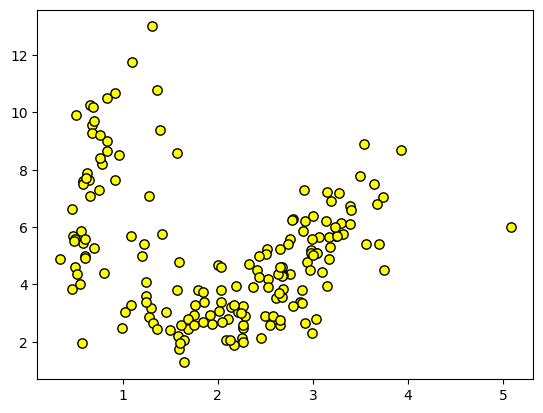

In [5]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(X[:, 0], X[:, 1], c="#94a3b8", edgecolor="white", s=55)
ax.set(title="Unlabeled observations", xlabel="x", ylabel="y")
plt.show()

## 4. Build the first model

Start with the original example's values: `eps=0.6`, `min_samples=5`.

- Smaller `eps` or larger `min_samples` makes clustering stricter and typically creates more noise.
- Larger `eps` or smaller `min_samples` merges regions more easily.
- There is no universal "right" pair; use domain knowledge, a nearest-neighbor distance plot, and a check of the resulting clusters.

### Make the assumptions explicit

Change just one of these values, rerun from here, and compare the summary and chart below. That is the core model-building loop.

In [6]:
EPS = 0.6
MIN_SAMPLES = 5

model = DBSCAN(eps=EPS, min_samples=MIN_SAMPLES)

## 5. Fit and evaluate

Clustering is unsupervised: there is no target label to predict. Here, "evaluate" means checking whether the discovered cluster structure and noise rate make sense for the problem.

In [7]:
labels = model.fit_predict(X)
core_mask = np.zeros(len(X), dtype=bool)
core_mask[model.core_sample_indices_] = True

DBSCAN(eps=0.6)

In [8]:
cluster_labels = sorted(label for label in np.unique(labels) if label != -1)
summary = {
    "eps": EPS,
    "min_samples": MIN_SAMPLES,
    "clusters_found": len(cluster_labels),
    "noise_points": int((labels == -1).sum()),
    "noise_rate": f"{(labels == -1).mean():.1%}",
    "core_points": int(core_mask.sum()),
    "border_points": int(((labels != -1) & ~core_mask).sum()),
}
pd.Series(summary, name="result")

In [9]:
pd.Series(labels, name="cluster").value_counts().sort_index().rename_axis("label").to_frame("points")

array([ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0, -1,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0, -1,  0,
        0,  0,  0,  0,  0,  0,  0,  0, -1,  0,  1,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0, -1,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0, -1,  0,  0,  0,  0,  0,  0,  0,  0,  0,  1,  1,  1,  1,  2,
        1,  1,  1,  1,  1,  1,  1,  1,  2,  1,  1,  2,  2, -1, -1,  2,  2,
        2,  2,  2,  2,  2, -1, -1,  2,  1,  1,  1,  2,  2,  2,  2,  2,  2,
        1,  2,  2,  2,  2,  2,  2,  2], dtype=int64)

## 6. Explain the result visually

Large circles are core points, smaller circles are border points, and `×` marks noise. The color is the cluster ID; IDs are arbitrary labels, not a ranking or category name.

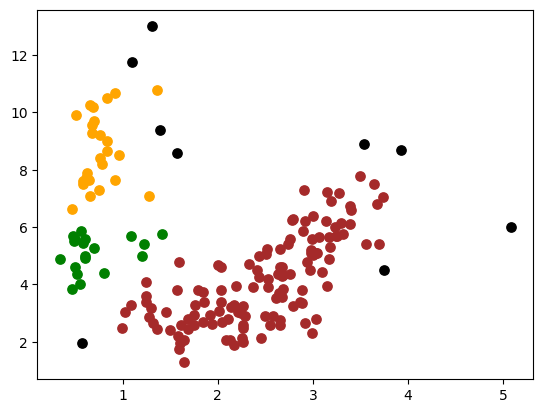

In [10]:
fig, ax = plt.subplots(figsize=(8, 6))

for label in cluster_labels:
    in_cluster = labels == label
    color = plt.cm.tab10(label % 10)
    ax.scatter(
        X[in_cluster & core_mask, 0], X[in_cluster & core_mask, 1],
        s=95, color=color, edgecolor="white", linewidth=0.8,
        label=f"Cluster {label} core"
    )
    ax.scatter(
        X[in_cluster & ~core_mask, 0], X[in_cluster & ~core_mask, 1],
        s=35, color=color, alpha=0.65, label=f"Cluster {label} border"
    )

noise = labels == -1
ax.scatter(X[noise, 0], X[noise, 1], marker="x", s=65, color="#111827", label="Noise")
ax.set(title=f"DBSCAN: eps={EPS}, min_samples={MIN_SAMPLES}", xlabel="x", ylabel="y")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [ ]:
# A k-distance plot gives a data-informed starting range for eps.
# The distance to the MIN_SAMPLES-th nearest neighbor is sorted; look for a bend.
neighbor_model = NearestNeighbors(n_neighbors=MIN_SAMPLES).fit(X)
distances, _ = neighbor_model.kneighbors(X)
k_distances = np.sort(distances[:, -1])

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(k_distances, color="#2563eb")
ax.axhline(EPS, color="#dc2626", linestyle="--", label=f"current eps = {EPS}")
ax.set(
    title=f"{MIN_SAMPLES}-nearest-neighbor distances",
    xlabel="Observations sorted by distance",
    ylabel="Distance to neighbor",
)
ax.legend()
plt.show()

## Your two-minute experiment

1. Change `EPS` from `0.6` to `0.45`, rerun cells 12–19, and record the cluster and noise counts.
2. Restore `EPS=0.6`, change `MIN_SAMPLES` from `5` to `8`, and rerun cells 12–19.
3. Ask: did the change split clusters, merge clusters, or turn border points into noise? Is that behavior plausible for the real-world meaning of these coordinates?

For a portfolio project, add a short README section that states the business question, why these two features were selected, how feature scale was handled, the final parameter rationale, and what you would do with noise points. Do not describe cluster labels as ground truth unless you have external labels to validate them.